In [1]:
# pip install kagglehub[pandas-datasets]

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

In [47]:
# Original source: samartalwar/sleep-debt-and-screen-time-late-night-phone-habits on Kaggle.
# Analysis uses the saved CSV below; no download or overwrite is needed.


In [48]:
# load from csv, assuming the file is data/bedtime_screentime_sleep_debt.csv

df = pd.read_csv("data/bedtime_screentime_sleep_debt.csv")

In [49]:
df.describe()

,age,bedtime_phone_minutes,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score
count,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000
mean,34.355647,59.250000,55.153882,0.467765,33.222471,35.701412,40.671471,6.266209,21.735741,19.105859,2.766000,3.794671
std,11.584259,36.931991,19.850550,0.498989,51.935645,20.819390,17.444914,1.446258,3.069377,2.546459,1.695407,2.685153
min,18.000000,1.000000,10.000000,0.000000,0.000000,0.000000,6.000000,3.200000,8.100000,9.600000,0.000000,1.000000
25%,25.000000,31.000000,42.000000,0.000000,0.000000,21.000000,28.200000,5.240000,19.700000,17.400000,2.000000,1.100000
50%,32.000000,51.000000,55.000000,0.000000,0.000000,35.000000,37.600000,6.330000,21.900000,19.100000,3.000000,3.200000
75%,42.000000,79.000000,69.000000,1.000000,55.000000,50.000000,49.700000,7.350000,23.900000,20.800000,4.000000,5.600000
max,65.000000,180.000000,100.000000,1.000000,250.000000,112.000000,123.300000,9.800000,28.000000,27.000000,7.000000,10.000000


In [50]:
df.columns

Index(['user_id', 'age', 'gender', 'occupation_type', 'chronotype',
       'bedtime_phone_minutes', 'primary_bedtime_app', 'screen_brightness_pct',
       'blue_light_filter_active', 'caffeine_post_5pm_mg',
       'physical_activity_min', 'sleep_latency_min', 'total_sleep_hours',
       'deep_sleep_pct', 'rem_sleep_pct', 'morning_alarm_snoozes',
       'next_day_fatigue_score', 'sleep_debt_category'],
      dtype='object')

In [51]:
df['occupation_type'].unique()

array(['Healthcare / Shift Worker', 'Student', 'Remote Tech',
       'Freelance / Creative', 'Corporate 9-to-5'], dtype=object)

In [52]:
df['primary_bedtime_app'].unique()

array(['Instagram / Reddit', 'YouTube', 'TikTok / Reels',
       'News / Reading', 'Streaming (Netflix/Hulu)', 'Messaging / Chat'],
      dtype=object)

## Phone -> Sleep -> Fatigue
How are late-night phone habits associated with sleep quality, and how do those sleep differences relate to next-day fatigue?

### Part 1 — The Screen-Time Effect

Start with associations between bedtime phone duration and sleep. **REM/deep percentages**
measure sleep composition; **REM/deep minutes** also depend on total sleep duration. We
examine both so a stable percentage is not mistaken for stable time asleep. Sleep debt is
a recorded category, not a measured number of hours owed.

The arrows in this narrative organize the questions; they do not establish causation or
mediation. These are between-person associations in the available records, not changes
observed when one person alters their habits. Dataset provenance and the category-generation
rules are not established by the CSV.

8,500 rows retained; 0 excluded for missing fields.


,mean,median,std
total_sleep_hours,6.27,6.33,1.45
rem_sleep_pct,19.11,19.10,2.55
deep_sleep_pct,21.74,21.90,3.07
rem_minutes,71.91,71.41,19.52
deep_minutes,82.19,82.16,23.64


,n,total_sleep_hours,rem_sleep_pct,deep_sleep_pct,rem_minutes,deep_minutes
screen_range,,,,,,
0–30,2051,7.15,19.07,22.59,81.95,96.97
>30–60,3038,6.58,19.17,22.04,75.77,87.18
>60–90,1866,5.88,19.09,21.42,67.31,75.58
>90–120,907,5.28,19.07,20.67,60.52,65.68
>120,638,4.45,19.02,19.96,50.85,53.74


sleep_debt_category,Optimal Recovery,Mild Deficit,Moderate Debt,Severe Sleep Debt
screen_range,,,,
0–30,34.7,29.3,35.9,0.1
>30–60,17.8,30.9,50.5,0.8
>60–90,6.6,20.2,67.0,6.2
>90–120,1.2,8.0,73.8,17.0
>120,0.0,2.2,42.9,54.9


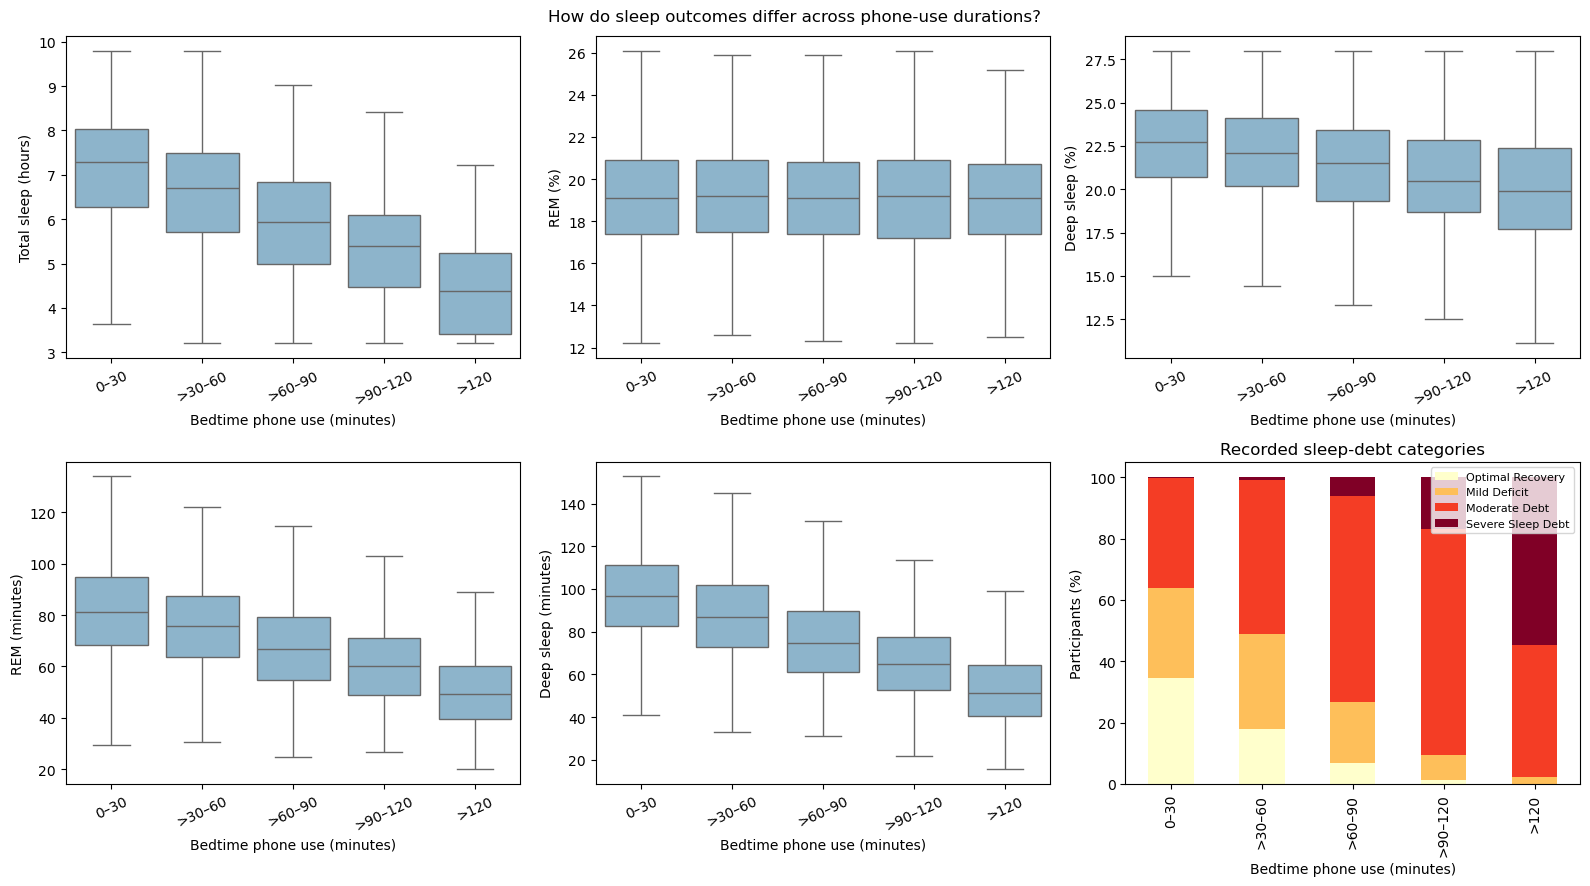

In [53]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import build_design_matrices
from IPython.display import display

# Reuse the loaded data; keep derived columns in one frame shared across all three parts.
phone_story = df.copy()
story_required = ['user_id', 'bedtime_phone_minutes', 'total_sleep_hours', 'rem_sleep_pct',
    'deep_sleep_pct', 'sleep_debt_category', 'next_day_fatigue_score', 'primary_bedtime_app',
    'screen_brightness_pct', 'blue_light_filter_active', 'caffeine_post_5pm_mg',
    'physical_activity_min', 'age', 'gender', 'occupation_type', 'chronotype']
phone_story = phone_story.dropna(subset=story_required).copy()
assert phone_story.user_id.is_unique, 'Repeated users require clustered inference.'
phone_story['screen_30'] = phone_story.bedtime_phone_minutes / 30
phone_story['rem_minutes'] = phone_story.total_sleep_hours * 60 * phone_story.rem_sleep_pct / 100
phone_story['deep_minutes'] = phone_story.total_sleep_hours * 60 * phone_story.deep_sleep_pct / 100
phone_story['severe_debt'] = phone_story.sleep_debt_category.eq('Severe Sleep Debt').astype(int)
story_debt_order = ['Optimal Recovery', 'Mild Deficit', 'Moderate Debt', 'Severe Sleep Debt']
assert set(phone_story.sleep_debt_category) <= set(story_debt_order)
story_ranges = ['0–30', '>30–60', '>60–90', '>90–120', '>120']
phone_story['screen_range'] = pd.cut(phone_story.bedtime_phone_minutes,
    [0, 30, 60, 90, 120, np.inf], labels=story_ranges, include_lowest=True)
story_outcomes = {'total_sleep_hours': 'Total sleep (hours)', 'rem_sleep_pct': 'REM (%)',
    'deep_sleep_pct': 'Deep sleep (%)', 'rem_minutes': 'REM (minutes)', 'deep_minutes': 'Deep sleep (minutes)'}
story_controls = ('C(primary_bedtime_app) + screen_brightness_pct + blue_light_filter_active + '
    'caffeine_post_5pm_mg + physical_activity_min + age + C(gender) + C(occupation_type) + C(chronotype)')
story_rhs = 'screen_30 + ' + story_controls
story_notes = {}
print(f'{len(phone_story):,} rows retained; {len(df) - len(phone_story)} excluded for missing fields.')
story_baseline = phone_story[list(story_outcomes)].agg(['mean', 'median', 'std']).T
story_screen_summary = phone_story.groupby('screen_range', observed=True)[list(story_outcomes)].mean()
story_screen_summary.insert(0, 'n', phone_story.groupby('screen_range', observed=True).size())
story_debt_shares = pd.crosstab(phone_story.screen_range, phone_story.sleep_debt_category,
    normalize='index').reindex(columns=story_debt_order) * 100
display(story_baseline.round(2), story_screen_summary.round(2), story_debt_shares.round(1))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (outcome, label) in zip(axes.flat, story_outcomes.items()):
    sns.boxplot(data=phone_story, x='screen_range', y=outcome, color='#83b6d5', showfliers=False, ax=ax)
    ax.set(xlabel='Bedtime phone use (minutes)', ylabel=label)
    ax.tick_params(axis='x', rotation=25)
story_debt_shares.plot.bar(stacked=True, ax=axes.flat[-1], colormap='YlOrRd')
axes.flat[-1].set(xlabel='Bedtime phone use (minutes)', ylabel='Participants (%)', title='Recorded sleep-debt categories')
axes.flat[-1].legend(fontsize=8)
fig.suptitle('How do sleep outcomes differ across phone-use durations?')
plt.tight_layout()
plt.show()

The tables give sample sizes and unadjusted averages; the boxplots also show dispersion
(outliers are hidden). The stacked bars compare category shares, avoiding a misleading
numerical score for sleep debt. Next, estimate an average difference per 30 phone minutes,
both before and after controlling for recorded behaviors and demographic factors.

In [54]:
story_sleep_models, story_effect_rows = {}, []
for outcome, label in story_outcomes.items():
    for adjustment, rhs in [('Unadjusted', 'screen_30'), ('Adjusted', story_rhs)]:
        model = smf.ols(f'{outcome} ~ {rhs}', data=phone_story).fit(cov_type='HC3')
        if adjustment == 'Adjusted':
            story_sleep_models[outcome] = model
        low, high = model.conf_int().loc['screen_30']
        story_effect_rows.append({'outcome': label, 'model': adjustment,
            'difference per +30 phone minutes': model.params['screen_30'],
            '95% CI lower': low, '95% CI upper': high})
story_screen_effects = pd.DataFrame(story_effect_rows).set_index(['outcome', 'model'])
display(story_screen_effects.round(3))

# For debt, model the probability of the recorded severe category rather than ordinal codes.
story_debt_model = smf.glm('severe_debt ~ ' + story_rhs, data=phone_story,
    family=sm.families.Binomial()).fit(cov_type='HC3')
story_sleep_models['severe_debt'] = story_debt_model
debt_or = np.exp(story_debt_model.params['screen_30'])
debt_or_ci = np.exp(story_debt_model.conf_int().loc['screen_30'])
display(pd.DataFrame({'odds ratio per +30 phone minutes': [debt_or],
    '95% CI lower': [debt_or_ci.iloc[0]], '95% CI upper': [debt_or_ci.iloc[1]]}))

def story_effect_text(outcome):
    row = story_screen_effects.loc[(story_outcomes[outcome], 'Adjusted')]
    return (f"{row.iloc[0]:+.2f} (95% CI {row.iloc[1]:+.2f} to {row.iloc[2]:+.2f})")

story_notes['part1'] = (
    '**What this shows:** For each additional 30 minutes of bedtime phone use, adjusted '
    'total sleep differs by **' + story_effect_text('total_sleep_hours') + ' hours**, '
    'REM duration by **' + story_effect_text('rem_minutes') + ' minutes**, and deep-sleep '
    'duration by **' + story_effect_text('deep_minutes') + ' minutes**. The REM-percentage '
    'difference is ' + story_effect_text('rem_sleep_pct') + ' percentage points; the '
    'deep-sleep-percentage difference is ' + story_effect_text('deep_sleep_pct') + ' percentage points. '
    'Thus duration and sleep composition can tell different stories. Derived stage minutes '
    'are calculated from total sleep and stage percentage, not an independent measurement. '
    f'The adjusted odds ratio for the severe-debt category is {debt_or:.2f} '
    f'(95% CI {debt_or_ci.iloc[0]:.2f}–{debt_or_ci.iloc[1]:.2f}) per 30 minutes. '
    'An odds ratio is not a probability ratio. These models assume linear continuous-outcome '
    'slopes and linear log-odds for severe debt; intervals use HC3 robust standard errors. '
    'A category association does not reveal how many hours of debt accumulate.')

difference per +30 phone minutes  \
outcome              model                                          
Total sleep (hours)  Unadjusted                            -0.651   
                     Adjusted                              -0.662   
REM (%)              Unadjusted                            -0.018   
                     Adjusted                              -0.015   
Deep sleep (%)       Unadjusted                            -0.652   
                     Adjusted                              -0.653   
REM (minutes)        Unadjusted                            -7.527   
                     Adjusted                              -7.638   
Deep sleep (minutes) Unadjusted                           -10.609   
                     Adjusted                             -10.752   

                                 95% CI lower  95% CI upper  
outcome              model                                   
Total sleep (hours)  Unadjusted        -0.670        -0.632  
                     Adjusted          -0.674        -0.650  
REM (%)              Unadjusted        -0.061         0.026  
                     Adjusted          -0.052         0.023  
Deep sleep (%)       Unadjusted        -0.706        -0.598  
                     Adjusted          -0.698        -0.608  
REM (minutes)        Unadjusted        -7.799        -7.255  
                     Adjusted          -7.821        -7.455  
Deep sleep (minutes) Unadjusted       -10.928       -10.290  
                     Adjusted         -10.972       -10.533

,odds ratio per +30 phone minutes,95% CI lower,95% CI upper
0,11.828384,10.0264,13.954227


**What this shows:** For each additional 30 minutes of bedtime phone use, adjusted total sleep differs by **-0.66 (95% CI -0.67 to -0.65) hours**, REM duration by **-7.64 (95% CI -7.82 to -7.45) minutes**, and deep-sleep duration by **-10.75 (95% CI -10.97 to -10.53) minutes**. The REM-percentage difference is -0.01 (95% CI -0.05 to +0.02) percentage points; the deep-sleep-percentage difference is -0.65 (95% CI -0.70 to -0.61) percentage points. Thus duration and sleep composition can tell different stories. Derived stage minutes are calculated from total sleep and stage percentage, not an independent measurement. The adjusted odds ratio for the severe-debt category is 11.83 (95% CI 10.03–13.95) per 30 minutes. An odds ratio is not a probability ratio. These models assume linear continuous-outcome slopes and linear log-odds for severe debt; intervals use HC3 robust standard errors. A category association does not reveal how many hours of debt accumulate.

### Part 2 — Does the Way You Use Your Phone Matter?

Hold phone duration at **60 minutes**, then compare app category, brightness, and filter
status. Each model adds the relevant screen-time interaction to the Part 1 adjustment
set. We average predictions over the same participants' other recorded characteristics,
so comparisons are standardized to a shared population. The contrast combines the
factor's main effect and its interaction at 60 minutes: it differs from asking only
whether that factor changes the screen-time slope.

App categories are compared with **News / Reading**, brightness is compared at **75% vs
25%**, and filtering at **ON vs OFF**. These are descriptive reference choices. Probability
differences refer only to **Severe Sleep Debt**, not every debt category.

In [55]:
# Return an average adjusted prediction and its gradient for uncertainty/paired contrasts.
def story_standardize(model, settings, probability=False):
    scenario = phone_story.assign(screen_30=2, **settings)
    design = np.asarray(build_design_matrices([model.model.data.design_info], scenario)[0])
    if probability:
        prediction = np.asarray(model.predict(scenario))
        value = prediction.mean() * 100
        gradient = (design * (prediction * (1 - prediction))[:, None]).mean(axis=0) * 100
    else:
        gradient = design.mean(axis=0)
        value = float(gradient @ model.params)
    return value, gradient

def story_interval(model, value, gradient):
    se = np.sqrt(max(float(gradient @ np.asarray(model.cov_params()) @ gradient), 0))
    return value - 1.96 * se, value + 1.96 * se

story_conditions = {
    'app': ('screen_30:C(primary_bedtime_app)', 'News / Reading',
        {name: {'primary_bedtime_app': name} for name in sorted(phone_story.primary_bedtime_app.unique())}),
    'brightness': ('screen_30:screen_brightness_pct', '25% brightness',
        {'25% brightness': {'screen_brightness_pct': 25}, '75% brightness': {'screen_brightness_pct': 75}}),
    'filter': ('screen_30:blue_light_filter_active', 'Filter OFF',
        {'Filter OFF': {'blue_light_filter_active': 0}, 'Filter ON': {'blue_light_filter_active': 1}})
}
story_condition_models, story_predictions, story_contrasts = {}, {}, {}

def story_compare_conditions(factor):
    interaction, reference_label, scenarios = story_conditions[factor]
    predictions, contrasts = [], []
    for outcome in list(story_outcomes) + ['severe_debt']:
        probability = outcome == 'severe_debt'
        label = 'Severe debt probability (%)' if probability else story_outcomes[outcome]
        formula = f'{outcome} ~ {story_rhs} + {interaction}'
        model = (smf.glm(formula, data=phone_story, family=sm.families.Binomial()).fit(cov_type='HC3')
                 if probability else smf.ols(formula, data=phone_story).fit(cov_type='HC3'))
        story_condition_models[(factor, outcome)] = model
        ref_value, ref_gradient = story_standardize(model, scenarios[reference_label], probability)
        for condition, settings in scenarios.items():
            value, gradient = story_standardize(model, settings, probability)
            low, high = story_interval(model, value, gradient)
            predictions.append({'condition': condition, 'outcome': label, 'adjusted mean at 60 min': value,
                '95% CI lower': low, '95% CI upper': high})
            if condition != reference_label:
                difference = value - ref_value
                low, high = story_interval(model, difference, gradient - ref_gradient)
                contrasts.append({'condition': condition, 'reference': reference_label, 'outcome': label,
                    'difference at 60 min': difference, '95% CI lower': low, '95% CI upper': high})
    story_predictions[factor] = pd.DataFrame(predictions)
    story_contrasts[factor] = pd.DataFrame(contrasts)
    display(story_predictions[factor].pivot(index='condition', columns='outcome', values='adjusted mean at 60 min').round(2))
    display(story_contrasts[factor].set_index(['condition', 'outcome']).round(3))
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, label in zip(axes, ['Total sleep (hours)', 'REM (minutes)', 'Deep sleep (minutes)']):
        plot = story_predictions[factor].query('outcome == @label').reset_index(drop=True)
        ax.errorbar(plot['adjusted mean at 60 min'], np.arange(len(plot)),
            xerr=[plot['adjusted mean at 60 min'] - plot['95% CI lower'], plot['95% CI upper'] - plot['adjusted mean at 60 min']],
            fmt='o', capsize=3)
        ax.set(yticks=np.arange(len(plot)), yticklabels=plot.condition, xlabel=label)
    fig.suptitle(f'At 60 phone minutes: adjusted sleep outcomes by {factor} (95% intervals)')
    plt.tight_layout()
    plt.show()

def story_condition_note(factor):
    rows = story_contrasts[factor]
    sentences = []
    for _, row in rows.loc[rows.outcome == 'REM (minutes)'].iterrows():
        sentences.append(f"**{row['condition']} vs {row['reference']}**: {row['difference at 60 min']:+.2f} "
            f"REM minutes (95% CI {row['95% CI lower']:+.2f} to {row['95% CI upper']:+.2f}).")
    return ('**At the same 60-minute duration:** ' + ' '.join(sentences) +
        ' The tables also show total sleep, deep sleep, stage percentages, and severe-debt probability. '
        'For the probability outcome, contrasts are percentage points. Intervals that include zero '
        'do not clearly distinguish the conditions. These are model-based associations, not the '
        'expected causal effect of switching a setting or app. Intervals are pointwise and are not '
        'corrected for the many outcome/condition comparisons; app rankings are exploratory.')

,observations at 45–75 phone minutes
primary_bedtime_app,
Instagram / Reddit,526
Messaging / Chat,236
News / Reading,191
Streaming (Netflix/Hulu),408
TikTok / Reels,665
YouTube,586


outcome,Deep sleep (%),Deep sleep (minutes),REM (%),REM (minutes),Severe debt probability (%),Total sleep (hours)
condition,,,,,,
Instagram / Reddit,21.67,81.49,18.86,70.52,2.06,6.23
Messaging / Chat,21.69,82.55,19.45,73.63,1.47,6.32
News / Reading,21.81,83.78,20.61,78.76,1.53,6.37
Streaming (Netflix/Hulu),21.79,82.88,19.91,75.37,1.44,6.31
TikTok / Reels,21.72,80.79,18.04,66.71,3.38,6.16
YouTube,21.69,82.11,19.37,72.92,2.20,6.27


,,reference,difference at 60 min,95% CI lower,95% CI upper
condition,outcome,,,,
Instagram / Reddit,Total sleep (hours),News / Reading,-0.140,-0.202,-0.078
Messaging / Chat,Total sleep (hours),News / Reading,-0.049,-0.117,0.019
Streaming (Netflix/Hulu),Total sleep (hours),News / Reading,-0.060,-0.124,0.004
TikTok / Reels,Total sleep (hours),News / Reading,-0.209,-0.269,-0.148
YouTube,Total sleep (hours),News / Reading,-0.097,-0.158,-0.036
Instagram / Reddit,REM (%),News / Reading,-1.743,-1.945,-1.541
Messaging / Chat,REM (%),News / Reading,-1.160,-1.386,-0.933
Streaming (Netflix/Hulu),REM (%),News / Reading,-0.698,-0.908,-0.488
TikTok / Reels,REM (%),News / Reading,-2.565,-2.762,-2.369


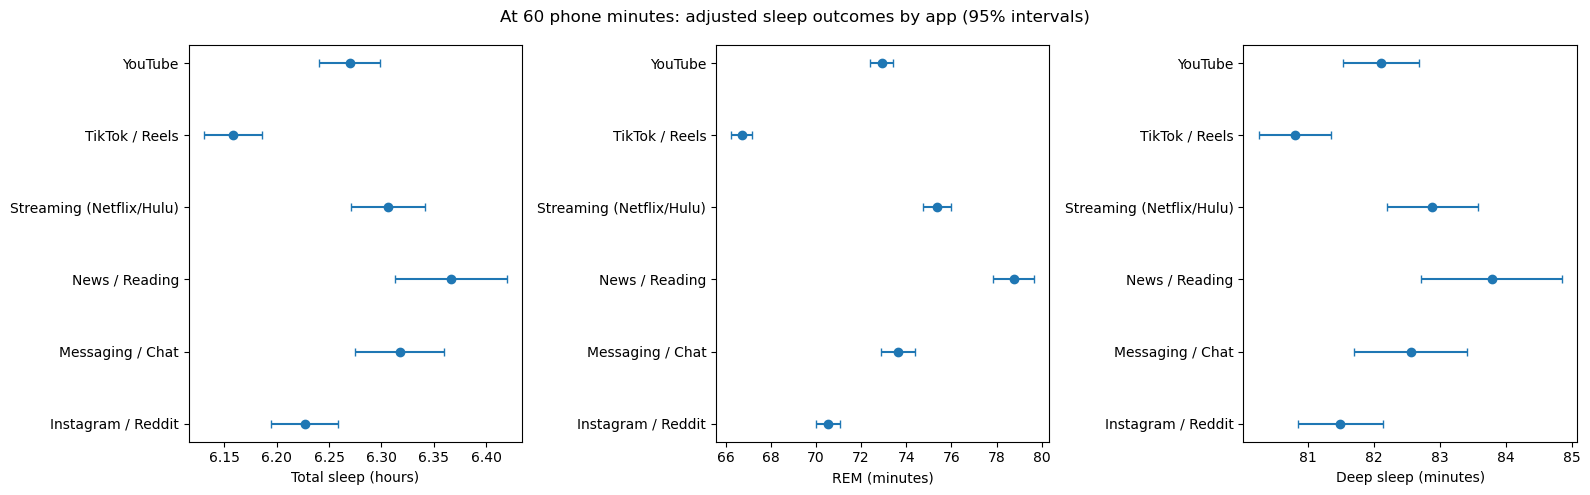

In [56]:
# App/category: compare like-duration use rather than each app's raw average.
story_near_hour = phone_story.loc[phone_story.bedtime_phone_minutes.between(45, 75)]
display(story_near_hour.groupby('primary_bedtime_app').size().rename('observations at 45–75 phone minutes').to_frame())
story_compare_conditions('app')
story_notes['app'] = story_condition_note('app')

**At the same 60-minute duration:** **Instagram / Reddit vs News / Reading**: -8.23 REM minutes (95% CI -9.29 to -7.17). **Messaging / Chat vs News / Reading**: -5.12 REM minutes (95% CI -6.31 to -3.93). **Streaming (Netflix/Hulu) vs News / Reading**: -3.39 REM minutes (95% CI -4.49 to -2.28). **TikTok / Reels vs News / Reading**: -12.05 REM minutes (95% CI -13.08 to -11.02). **YouTube vs News / Reading**: -5.84 REM minutes (95% CI -6.89 to -4.79). The tables also show total sleep, deep sleep, stage percentages, and severe-debt probability. For the probability outcome, contrasts are percentage points. Intervals that include zero do not clearly distinguish the conditions. These are model-based associations, not the expected causal effect of switching a setting or app. Intervals are pointwise and are not corrected for the many outcome/condition comparisons; app rankings are exploratory.

,brightness near one hour
count,2612.000000
mean,55.603752
std,19.683311
min,10.000000
25%,42.000000
50%,56.000000
75%,69.000000
max,100.000000


outcome,Deep sleep (%),Deep sleep (minutes),REM (%),REM (minutes),Severe debt probability (%),Total sleep (hours)
condition,,,,,,
25% brightness,22.44,85.01,19.11,72.22,1.04,6.30
75% brightness,21.25,79.89,19.10,71.38,3.22,6.22


reference  \
condition      outcome                                       
75% brightness Total sleep (hours)          25% brightness   
               REM (%)                      25% brightness   
               Deep sleep (%)               25% brightness   
               REM (minutes)                25% brightness   
               Deep sleep (minutes)         25% brightness   
               Severe debt probability (%)  25% brightness   

                                            difference at 60 min  \
condition      outcome                                             
75% brightness Total sleep (hours)                        -0.080   
               REM (%)                                    -0.004   
               Deep sleep (%)                             -1.196   
               REM (minutes)                              -0.834   
               Deep sleep (minutes)                       -5.117   
               Severe debt probability (%)                 2.181   

                                            95% CI lower  95% CI upper  
condition      outcome                                                  
75% brightness Total sleep (hours)                -0.114        -0.046  
               REM (%)                            -0.122         0.113  
               Deep sleep (%)                     -1.330        -1.062  
               REM (minutes)                      -1.432        -0.235  
               Deep sleep (minutes)               -5.805        -4.429  
               Severe debt probability (%)         1.534         2.828

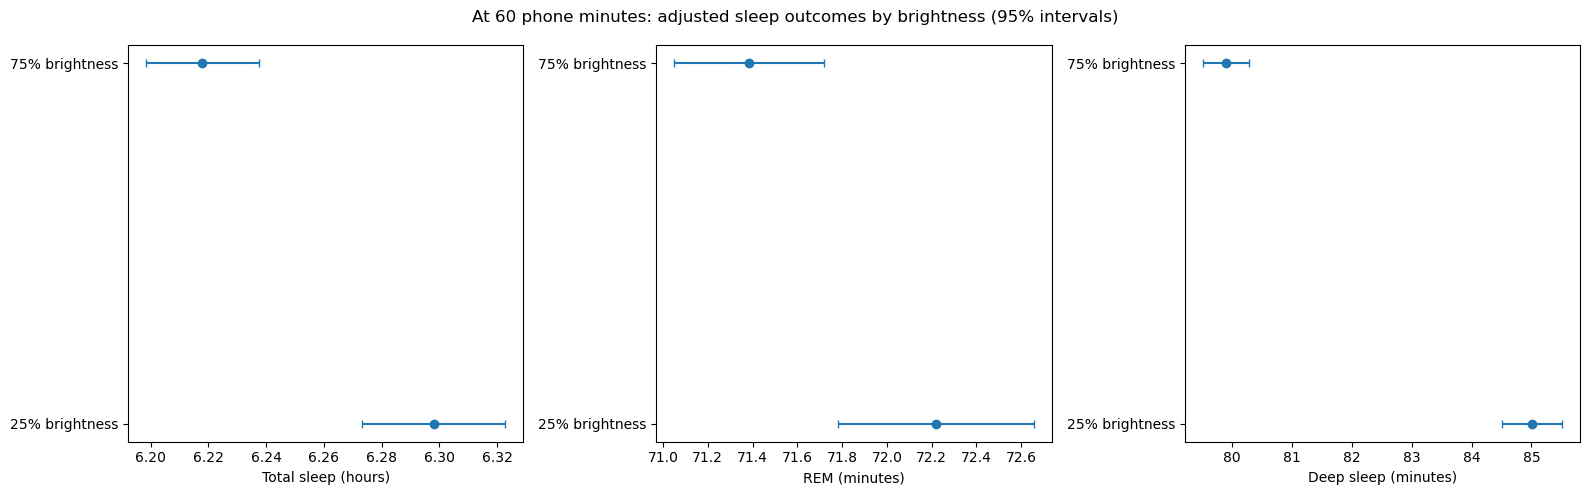

In [57]:
# Brightness: keep screen time at one hour and compare 25% with 75% brightness.
display(story_near_hour.screen_brightness_pct.describe().to_frame('brightness near one hour'))
story_compare_conditions('brightness')
story_notes['brightness'] = story_condition_note('brightness')

**At the same 60-minute duration:** **75% brightness vs 25% brightness**: -0.83 REM minutes (95% CI -1.43 to -0.24). The tables also show total sleep, deep sleep, stage percentages, and severe-debt probability. For the probability outcome, contrasts are percentage points. Intervals that include zero do not clearly distinguish the conditions. These are model-based associations, not the expected causal effect of switching a setting or app. Intervals are pointwise and are not corrected for the many outcome/condition comparisons; app rankings are exploratory.

,observations at 45–75 phone minutes
blue_light_filter_active,
0,1377
1,1235


outcome,Deep sleep (%),Deep sleep (minutes),REM (%),REM (minutes),Severe debt probability (%),Total sleep (hours)
condition,,,,,,
Filter OFF,21.39,80.51,19.10,71.44,2.79,6.23
Filter ON,22.09,83.53,19.11,72.02,1.66,6.27


reference  difference at 60 min  \
condition outcome                                                         
Filter ON Total sleep (hours)          Filter OFF                 0.046   
          REM (%)                      Filter OFF                 0.006   
          Deep sleep (%)               Filter OFF                 0.693   
          REM (minutes)                Filter OFF                 0.577   
          Deep sleep (minutes)         Filter OFF                 3.017   
          Severe debt probability (%)  Filter OFF                -1.124   

                                       95% CI lower  95% CI upper  
condition outcome                                                  
Filter ON Total sleep (hours)                 0.018         0.075  
          REM (%)                            -0.090         0.101  
          Deep sleep (%)                      0.584         0.803  
          REM (minutes)                       0.087         1.067  
          Deep sleep (minutes)                2.452         3.582  
          Severe debt probability (%)        -1.742        -0.505

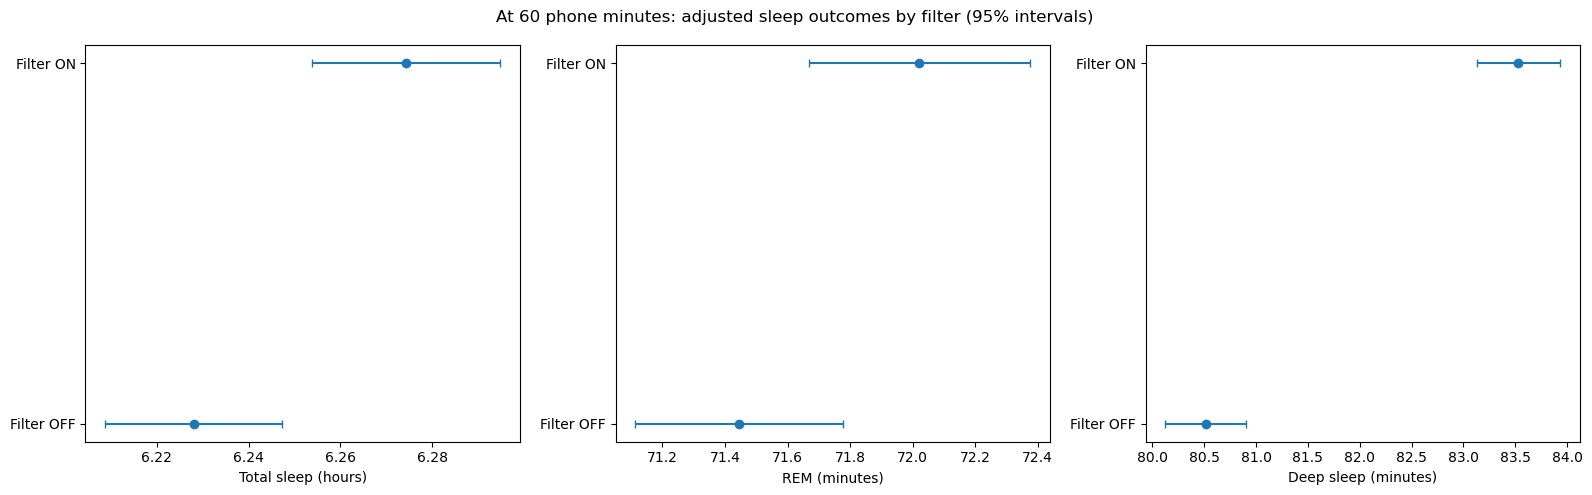

In [58]:
# Blue-light filter: standardize ON/OFF predictions to the same covariate distribution.
display(story_near_hour.groupby('blue_light_filter_active').size().rename('observations at 45–75 phone minutes').to_frame())
story_compare_conditions('filter')
story_notes['filter'] = story_condition_note('filter')

**At the same 60-minute duration:** **Filter ON vs Filter OFF**: +0.58 REM minutes (95% CI +0.09 to +1.07). The tables also show total sleep, deep sleep, stage percentages, and severe-debt probability. For the probability outcome, contrasts are percentage points. Intervals that include zero do not clearly distinguish the conditions. These are model-based associations, not the expected causal effect of switching a setting or app. Intervals are pointwise and are not corrected for the many outcome/condition comparisons; app rankings are exploratory.

**Timing and support:** The dataset measures bedtime phone duration, but has no clock
bedtime, phone-use start/end time, or interval between stopping phone use and falling
asleep. We therefore cannot test timing of use. Chronotype is an adjustment variable,
not a substitute for measured timing. Counts within 45–75 minutes check local support
for the one-hour comparison; they are not the sample used to fit the models. Even with
such support, uncommon combinations of covariates may require extrapolation.

### Part 3 — Does Poorer Sleep Show Up the Next Day?

Now use next-day fatigue as the outcome. First examine each sleep measure separately;
then adjust for the same phone behaviors and background characteristics. A joint model
includes total sleep and REM/deep **percentages** to distinguish duration from composition.
We do not put derived stage minutes into that same model, because they already combine
total sleep with percentages. Debt is analyzed separately as a category and is not added
to the joint sleep model, since it may encode overlapping sleep information.

,n,mean_fatigue,median_fatigue,mean_sleep_hours
sleep_debt_category,,,,
Optimal Recovery,1387,1.08,1.0,8.35
Mild Deficit,2004,1.83,1.4,7.23
Moderate Debt,4462,4.68,4.6,5.55
Severe Sleep Debt,647,9.58,9.9,3.76


,Pearson correlation with fatigue
total_sleep_hours,-0.879
rem_sleep_pct,-0.115
deep_sleep_pct,-0.341
rem_minutes,-0.798
deep_minutes,-0.848


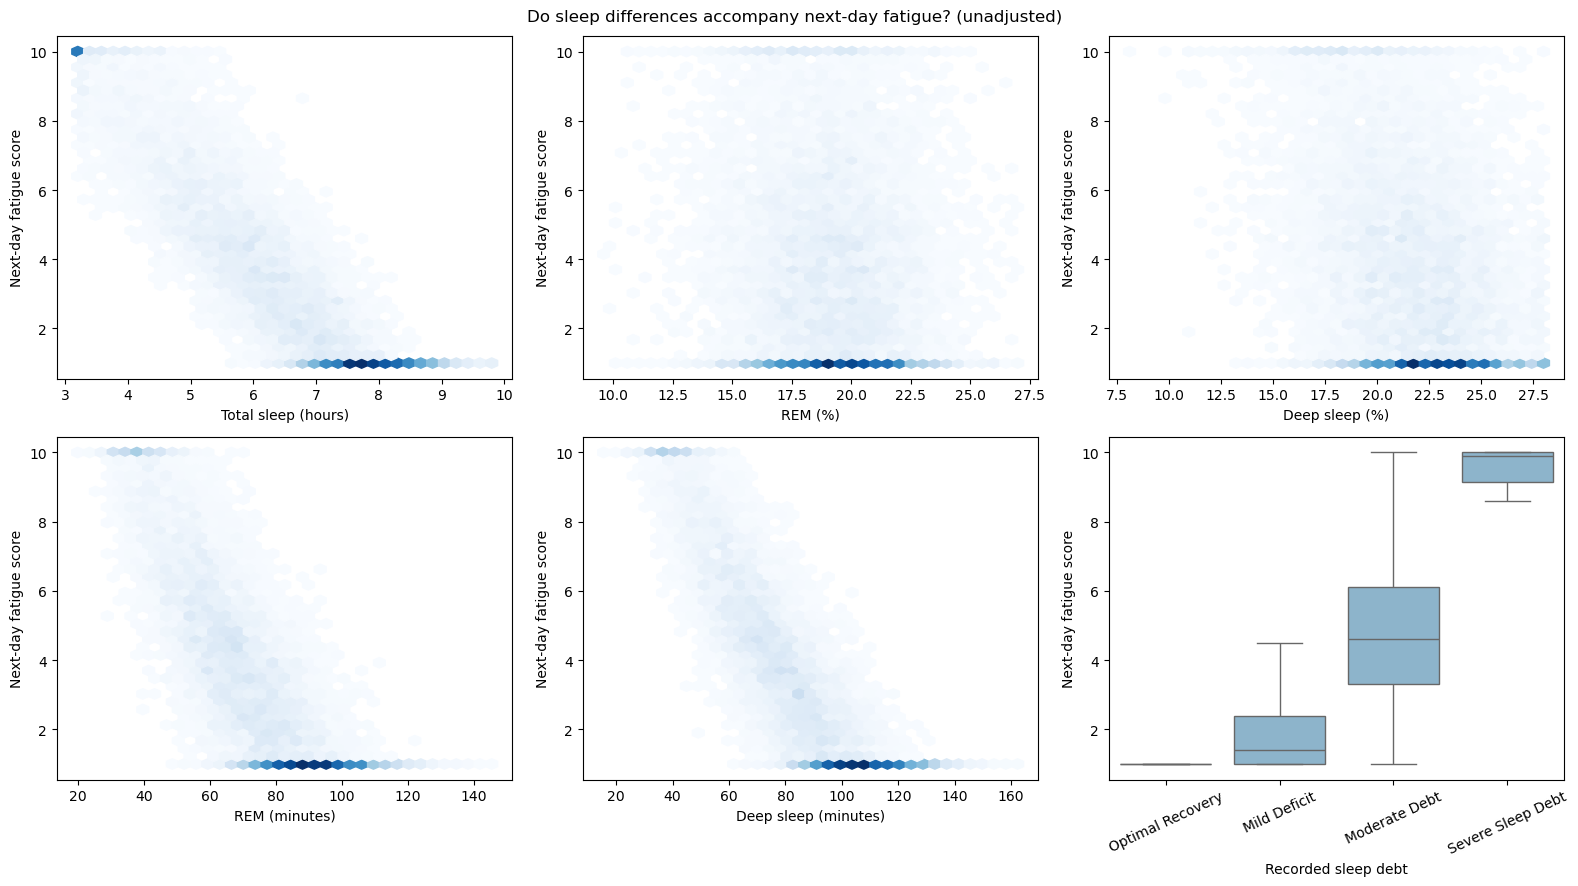

In [59]:
story_fatigue_summary = phone_story.groupby('sleep_debt_category').agg(
    n=('user_id', 'size'), mean_fatigue=('next_day_fatigue_score', 'mean'),
    median_fatigue=('next_day_fatigue_score', 'median'), mean_sleep_hours=('total_sleep_hours', 'mean')
).reindex(story_debt_order)
display(story_fatigue_summary.round(2))
story_sleep_correlations = phone_story[list(story_outcomes) + ['next_day_fatigue_score']].corr()['next_day_fatigue_score'].drop('next_day_fatigue_score')
display(story_sleep_correlations.rename('Pearson correlation with fatigue').to_frame().round(3))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (outcome, label) in zip(axes.flat, story_outcomes.items()):
    ax.hexbin(phone_story[outcome], phone_story.next_day_fatigue_score, gridsize=35, mincnt=1, cmap='Blues')
    ax.set(xlabel=label, ylabel='Next-day fatigue score')
sns.boxplot(data=phone_story, x='sleep_debt_category', y='next_day_fatigue_score',
    order=story_debt_order, color='#83b6d5', ax=axes.flat[-1], showfliers=False)
axes.flat[-1].set(xlabel='Recorded sleep debt', ylabel='Next-day fatigue score')
axes.flat[-1].tick_params(axis='x', rotation=25)
fig.suptitle('Do sleep differences accompany next-day fatigue? (unadjusted)')
plt.tight_layout()
plt.show()

The hexbin plots show the density of participants, reducing scatterplot overlap. Correlation
and category averages describe the sample but do not isolate each sleep measure. In the
next table, duration increments are **one hour of total sleep**, **30 minutes of REM/deep
sleep**, or **one percentage point** for stage percentages. Fatigue differences are score
points; compare effect sizes only after accounting for these different units.

In [60]:
story_fatigue_models, story_fatigue_rows = {}, []
story_sleep_steps = {'total_sleep_hours': 1, 'rem_sleep_pct': 1, 'deep_sleep_pct': 1,
                     'rem_minutes': 30, 'deep_minutes': 30}
for outcome, step in story_sleep_steps.items():
    for adjustment, rhs in [('Unadjusted', outcome), ('Adjusted', outcome + ' + ' + story_rhs)]:
        model = smf.ols('next_day_fatigue_score ~ ' + rhs, data=phone_story).fit(cov_type='HC3')
        story_fatigue_models[(outcome, adjustment)] = model
        low, high = model.conf_int().loc[outcome] * step
        story_fatigue_rows.append({'sleep measure': story_outcomes[outcome], 'increment': step,
            'model': adjustment, 'fatigue difference': model.params[outcome] * step,
            '95% CI lower': low, '95% CI upper': high})
story_fatigue_effects = pd.DataFrame(story_fatigue_rows)
display(story_fatigue_effects.set_index(['sleep measure', 'model']).round(3))

story_joint_sleep_model = smf.ols('next_day_fatigue_score ~ total_sleep_hours + rem_sleep_pct + '
    'deep_sleep_pct + ' + story_rhs, data=phone_story).fit(cov_type='HC3')
story_joint_terms = ['total_sleep_hours', 'rem_sleep_pct', 'deep_sleep_pct']
story_joint_results = pd.DataFrame({'fatigue difference': story_joint_sleep_model.params[story_joint_terms],
    '95% CI lower': story_joint_sleep_model.conf_int().loc[story_joint_terms, 0],
    '95% CI upper': story_joint_sleep_model.conf_int().loc[story_joint_terms, 1]})
display(story_joint_results.round(3))

story_debt_fatigue_model = smf.ols('next_day_fatigue_score ~ '
    'C(sleep_debt_category, Treatment(reference="Optimal Recovery")) + ' + story_rhs,
    data=phone_story).fit(cov_type='HC3')
story_debt_terms = [term for term in story_debt_fatigue_model.params.index if term.startswith('C(sleep_debt_category')]
story_debt_fatigue_results = pd.DataFrame({
    'fatigue difference vs Optimal Recovery': story_debt_fatigue_model.params[story_debt_terms],
    '95% CI lower': story_debt_fatigue_model.conf_int().loc[story_debt_terms, 0],
    '95% CI upper': story_debt_fatigue_model.conf_int().loc[story_debt_terms, 1]})
story_debt_fatigue_results.index = [term.split('[T.')[1].rstrip(']') for term in story_debt_terms]
display(story_debt_fatigue_results.round(3))

fatigue_sentences = []
for outcome in ['total_sleep_hours', 'rem_minutes', 'deep_minutes']:
    row = story_fatigue_effects.loc[(story_fatigue_effects['sleep measure'] == story_outcomes[outcome]) &
                                   (story_fatigue_effects['model'] == 'Adjusted')].iloc[0]
    unit = 'one additional hour of total sleep' if outcome == 'total_sleep_hours' else '30 additional minutes of ' + ('REM' if outcome == 'rem_minutes' else 'deep sleep')
    fatigue_sentences.append(f"{unit}: **{row['fatigue difference']:+.2f} fatigue points** "
        f"(95% CI {row['95% CI lower']:+.2f} to {row['95% CI upper']:+.2f})")
story_notes['part3'] = ('**What this shows:** In separate adjusted models, ' + '; '.join(fatigue_sentences) + '. '
    'These stage-duration associations are not independent of total sleep: inspect the joint '
    'model to see whether stage percentages add an association at a fixed total duration. '
    'At fixed total sleep, a percentage-point increase in one stage also implies less time '
    'in other stages, so its coefficient is a composition contrast. The debt table compares '
    'recorded categories with Optimal Recovery, adjusting for phone behaviors and background '
    'variables but not total sleep. No category-generation rule is known, so the debt association '
    'may partly repeat information already present in sleep duration. These are exploratory '
    'linear associations with a bounded fatigue score, not validated predictions or causal effects.')
story_notes['ending'] = (
    '**Phone behavior → Sleep outcomes → Next-day fatigue:** The strongest narrative is '
    'about how much sleep people get, while distinguishing stage duration from stage percentage. '
    'The first part quantifies the phone–sleep association; the second compares conditions '
    'at the same one-hour exposure; the third relates sleep differences to fatigue. '
    'Together they describe a connected pattern, but do not show that sleep mediates a causal '
    'phone effect. The models use the same observational sample and cannot establish temporal '
    'mechanisms, eliminate unmeasured confounding, or establish that changing a phone setting '
    'will improve sleep. Small point estimates with intervals spanning zero should not be '
    'presented as proven improvements or harms.')

increment  fatigue difference  95% CI lower  \
sleep measure        model                                                     
Total sleep (hours)  Unadjusted          1              -1.633        -1.652   
                     Adjusted            1              -1.253        -1.286   
REM (%)              Unadjusted          1              -0.121        -0.143   
                     Adjusted            1              -0.004        -0.016   
Deep sleep (%)       Unadjusted          1              -0.299        -0.316   
                     Adjusted            1              -0.073        -0.084   
REM (minutes)        Unadjusted         30              -3.295        -3.353   
                     Adjusted           30              -1.404        -1.472   
Deep sleep (minutes) Unadjusted         30              -2.891        -2.934   
                     Adjusted           30              -1.472        -1.529   

                                 95% CI upper  
sleep measure        model                     
Total sleep (hours)  Unadjusted        -1.614  
                     Adjusted          -1.221  
REM (%)              Unadjusted        -0.098  
                     Adjusted           0.009  
Deep sleep (%)       Unadjusted        -0.281  
                     Adjusted          -0.063  
REM (minutes)        Unadjusted        -3.238  
                     Adjusted          -1.336  
Deep sleep (minutes) Unadjusted        -2.848  
                     Adjusted          -1.416

,fatigue difference,95% CI lower,95% CI upper
total_sleep_hours,-1.250,-1.282,-1.218
rem_sleep_pct,-0.002,-0.011,0.007
deep_sleep_pct,-0.070,-0.077,-0.062


,fatigue difference vs Optimal Recovery,95% CI lower,95% CI upper
Mild Deficit,0.050,-0.007,0.107
Moderate Debt,1.561,1.479,1.644
Severe Sleep Debt,3.748,3.603,3.893


**What this shows:** In separate adjusted models, one additional hour of total sleep: **-1.25 fatigue points** (95% CI -1.29 to -1.22); 30 additional minutes of REM: **-1.40 fatigue points** (95% CI -1.47 to -1.34); 30 additional minutes of deep sleep: **-1.47 fatigue points** (95% CI -1.53 to -1.42). These stage-duration associations are not independent of total sleep: inspect the joint model to see whether stage percentages add an association at a fixed total duration. At fixed total sleep, a percentage-point increase in one stage also implies less time in other stages, so its coefficient is a composition contrast. The debt table compares recorded categories with Optimal Recovery, adjusting for phone behaviors and background variables but not total sleep. No category-generation rule is known, so the debt association may partly repeat information already present in sleep duration. These are exploratory linear associations with a bounded fatigue score, not validated predictions or causal effects.

**Joint-model result:** At fixed total sleep and recorded covariates, one additional REM percentage point is associated with -0.002 fatigue points (95% CI -0.011 to +0.007), providing no clear evidence of an independent REM-composition association. One additional deep-sleep percentage point is associated with -0.070 fatigue points (95% CI -0.077 to -0.062). Total sleep retains an association of -1.25 fatigue points per hour (95% CI -1.28 to -1.22).

**Debt-category result:** Relative to Optimal Recovery, adjusted fatigue is about 1.56 points higher for Moderate Debt (95% CI 1.48 to 1.64) and 3.75 points higher for Severe Sleep Debt (95% CI 3.60 to 3.89). The Mild Deficit contrast is small and its interval includes zero. This supports a descriptive link between poorer recorded sleep status and fatigue, without establishing the direction of causation.

**Phone behavior → Sleep outcomes → Next-day fatigue:** The strongest narrative is about how much sleep people get, while distinguishing stage duration from stage percentage. The first part quantifies the phone–sleep association; the second compares conditions at the same one-hour exposure; the third relates sleep differences to fatigue. Together they describe a connected pattern, but do not show that sleep mediates a causal phone effect. The models use the same observational sample and cannot establish temporal mechanisms, eliminate unmeasured confounding, or establish that changing a phone setting will improve sleep. Small point estimates with intervals spanning zero should not be presented as proven improvements or harms.

## What Makes Doomscrolling Worse?
If someone spends a long time on their phone before bed, what other behaviors are associated with making the sleep penalty larger or smaller?

We'll start by investigating a relationship between screen time and REM Sleep

In [61]:
# Investigating the relationship between REM sleep and screen time
rem = df['rem_sleep_pct'] 
bed_minutes = df['bedtime_phone_minutes']

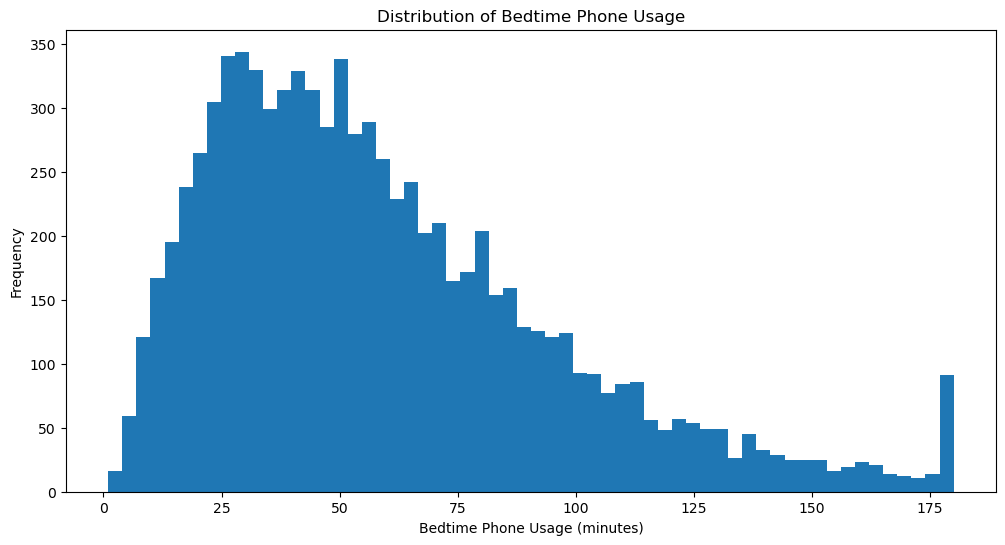

In [62]:

# Creating a histogram for bedtime phone usage
plt.figure(figsize=(12, 6))
plt.hist(bed_minutes, bins=60)
plt.xlabel('Bedtime Phone Usage (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of Bedtime Phone Usage')
plt.show()

More people tend to use up to an hour of their phone in bed.

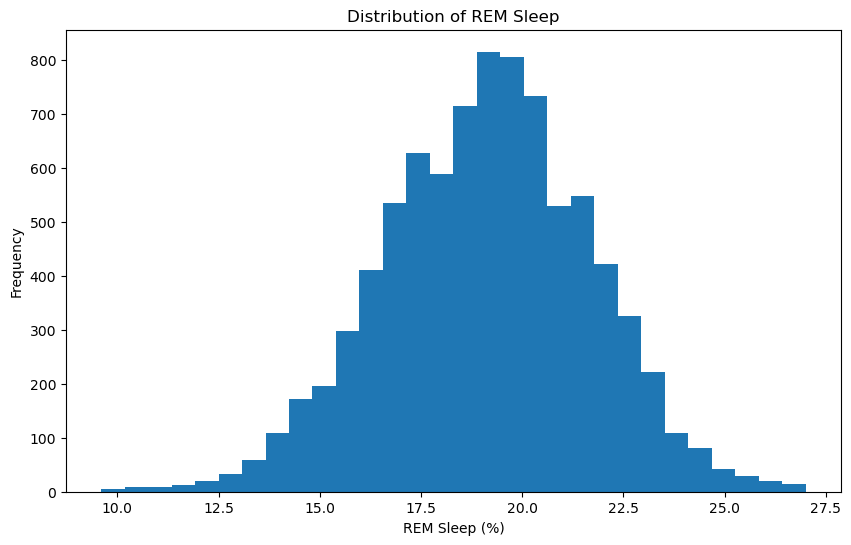

In [63]:
# Creating a histogram for REM sleep
plt.figure(figsize=(10, 6))
plt.hist(rem, bins=30)
plt.xlabel('REM Sleep (%)')
plt.ylabel('Frequency')
plt.title('Distribution of REM Sleep')
plt.show()


People tend to get around 15-22.5% REM Sleep.

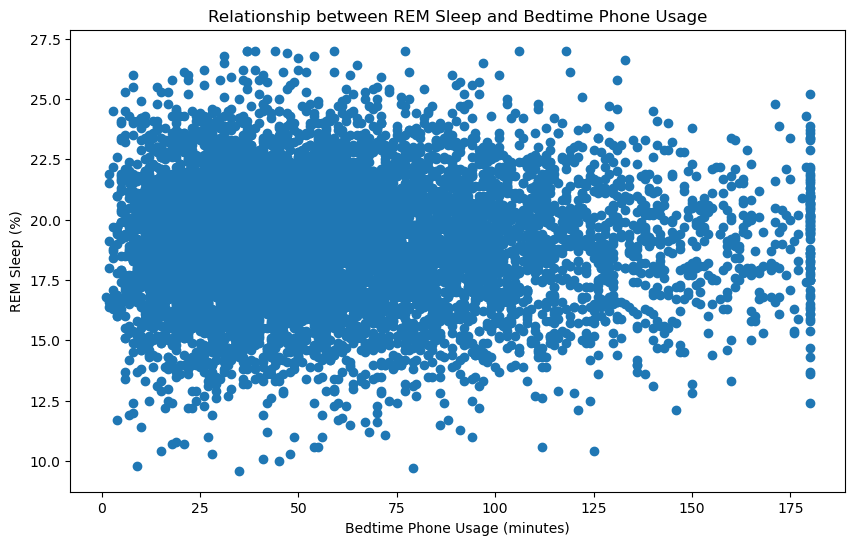

<Figure size 1000x600 with 0 Axes>

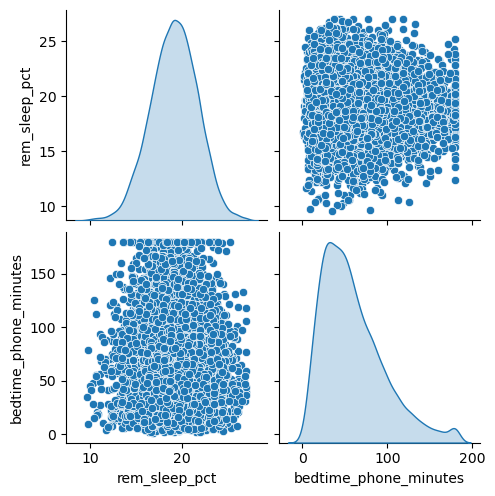

In [64]:
# Investigating relationship between REM sleep and bedtime phone usage through different types of plots
plt.figure(figsize=(10, 6))
plt.scatter(bed_minutes, rem)
plt.xlabel('Bedtime Phone Usage (minutes)')
plt.ylabel('REM Sleep (%)')
plt.title('Relationship between REM Sleep and Bedtime Phone Usage')
plt.show()

# Creating a pairplot for REM sleep and bedtime phone usage
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.pairplot(df[['rem_sleep_pct', 'bedtime_phone_minutes']], diag_kind='kde')
plt.show()

### Testing whether other behaviors change the screen-time penalty

The histograms describe the sample; the screen-time–REM scatter addresses the starting
association. Predictor-versus-predictor plots help inspect exposure patterns but do not
answer whether the REM slope changes. A **screen-time interaction** tests that slope change.

We retain `rem`, `bed_minutes`, `brightness`, `blue_light_filter`, `caffeine`, and `app`
from the exploration above. The outcome remains **REM percentage**, so an effect of -1
means one percentage point less REM, not one minute or a 1% relative decrease. A change
in REM percentage need not imply the same change in REM duration.

Each model adjusts for brightness, filter status, evening caffeine, app choice, physical
activity, age, gender, occupation, and chronotype. Interaction models add one interaction
at a time to the same baseline. This is exploratory association analysis, not evidence
that changing a behavior causes a change in sleep. Bedtime clock time, total daily screen
time, and sampling/provenance details are not available in the CSV.

In [65]:
app = df['primary_bedtime_app']
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from patsy import build_design_matrices
from IPython.display import display

brightness = df['screen_brightness_pct']
blue_light_filter = df['blue_light_filter_active']
caffeine = df['caffeine_post_5pm_mg']

# Reuse the Series already created above; use one complete-case sample for every model.
rem_analysis = df.assign(
    rem_pct=rem, screen_30=bed_minutes / 30,
    brightness_25=(brightness - 50) / 25,
    filter_on=blue_light_filter, caffeine_100=caffeine / 100,
    bedtime_app=app)
rem_columns = ['rem_pct', 'screen_30', 'brightness_25', 'filter_on', 'caffeine_100',
               'bedtime_app', 'physical_activity_min', 'age', 'gender', 'occupation_type', 'chronotype']
rem_analysis = rem_analysis[rem_columns].dropna().copy()
assert df.loc[rem_analysis.index, 'user_id'].is_unique, 'Repeated users require clustered inference.'
print(f'Analyzing {len(rem_analysis):,} of {len(df):,} rows; {len(df) - len(rem_analysis)} excluded for missing values.')
print('Filter values:', sorted(rem_analysis.filter_on.unique()))
assert set(rem_analysis.filter_on.unique()) <= {0, 1}
rem_main_formula = ('rem_pct ~ screen_30 + brightness_25 + filter_on + caffeine_100 + '
                    'C(bedtime_app) + physical_activity_min + age + C(gender) + '
                    'C(occupation_type) + C(chronotype)')
rem_models, rem_interpretations, rem_interaction_tests = {}, {}, {}

# A fixed typical profile makes the line plots comparable; only the displayed exposures vary.
rem_profile = rem_analysis.iloc[[0]].copy()
for column in rem_columns:
    rem_profile[column] = (rem_analysis[column].median() if pd.api.types.is_numeric_dtype(rem_analysis[column])
                           else rem_analysis[column].mode().iloc[0])
rem_profile['filter_on'] = 0

def rem_design(model, frame):
    return np.asarray(build_design_matrices([model.model.data.design_info], frame)[0])

def rem_slope_vector(model, settings):
    low = rem_profile.assign(screen_30=2, **settings)
    high = rem_profile.assign(screen_30=3, **settings)
    return (rem_design(model, high) - rem_design(model, low))[0]

def rem_contrast(model, vector):
    test = model.t_test(vector)
    low, high = np.asarray(test.conf_int()).ravel()
    return {'REM pp per +30 min': float(np.asarray(test.effect).item()),
            '95% CI lower': float(low), '95% CI upper': float(high),
            'p-value': float(np.asarray(test.pvalue).item())}

def rem_slope_table(model, scenarios):
    return pd.DataFrame({label: rem_contrast(model, rem_slope_vector(model, settings))
                         for label, settings in scenarios.items()}).T

def rem_interaction_test(model, key):
    terms = [i for i, name in enumerate(model.params.index) if ':' in name]
    restriction = np.eye(len(model.params))[terms]
    result = model.wald_test(restriction, use_f=True, scalar=True)
    p = float(result.pvalue)
    rem_interaction_tests[key] = {'interaction p-value': p, 'adjusted R2': model.rsquared_adj}
    return p

def rem_lines(model, scenarios, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    for label, settings in scenarios.items():
        grid = pd.concat([rem_profile] * 80, ignore_index=True)
        grid['screen_30'] = np.linspace(rem_analysis.screen_30.min(), rem_analysis.screen_30.max(), 80)
        for column, value in settings.items():
            grid[column] = value
        prediction = model.get_prediction(grid).summary_frame()
        x = grid.screen_30.to_numpy() * 30
        line, = ax.plot(x, prediction['mean'], label=label)
        ax.fill_between(x, prediction['mean_ci_lower'], prediction['mean_ci_upper'], alpha=0.10, color=line.get_color())
    ax.set(xlabel='Bedtime phone use (minutes)', ylabel='Predicted REM sleep (%)', title=title)
    ax.legend(title='Other covariates fixed at the same typical profile')
    plt.tight_layout()
    plt.show()

def rem_effect_sentence(result):
    return (f"{result['REM pp per +30 min']:+.3f} REM percentage points "
            f"(95% CI {result['95% CI lower']:+.3f} to {result['95% CI upper']:+.3f})")

Analyzing 8,500 of 8,500 rows; 0 excluded for missing values.
Filter values: [np.int64(0), np.int64(1)]


### Screen time → REM sleep

First estimate the unadjusted association, then the adjusted baseline that the following
four models share. All intervals use HC3 heteroskedasticity-robust standard errors.

,REM pp per +30 min,95% CI lower,95% CI upper,p-value
Unadjusted,-0.0177,-0.0613,0.0259,0.4262
Adjusted,-0.0146,-0.0520,0.0228,0.4437


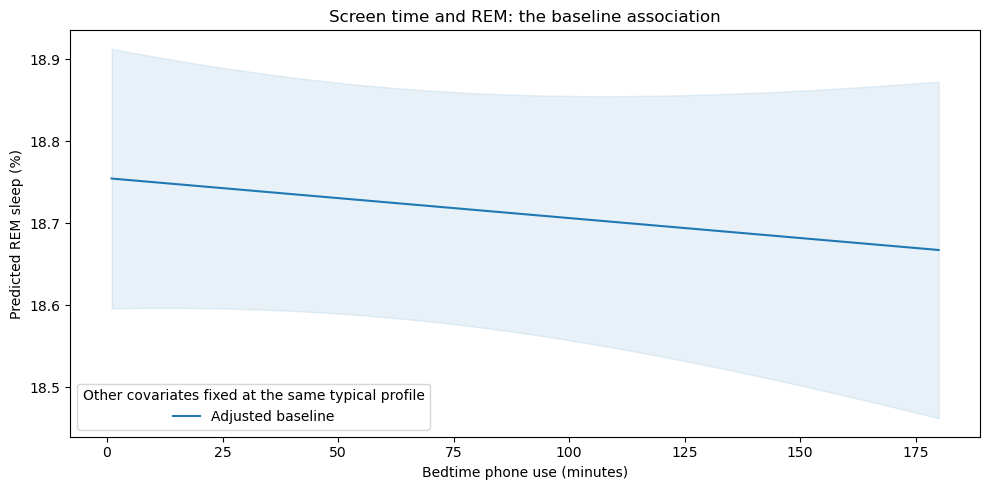

In [66]:
rem_unadjusted = smf.ols('rem_pct ~ screen_30', data=rem_analysis).fit(cov_type='HC3')
rem_baseline = smf.ols(rem_main_formula, data=rem_analysis).fit(cov_type='HC3')
rem_models['baseline'] = rem_baseline
rem_baseline_results = pd.DataFrame({
    'Unadjusted': rem_contrast(rem_unadjusted, rem_slope_vector(rem_unadjusted, {})),
    'Adjusted': rem_contrast(rem_baseline, rem_slope_vector(rem_baseline, {}))}).T
display(rem_baseline_results.round(4))
rem_lines(rem_baseline, {'Adjusted baseline': {}}, 'Screen time and REM: the baseline association')
baseline_effect = rem_baseline_results.loc['Adjusted'].to_dict()
rem_interpretations['baseline'] = (
    '**Outcome:** Each additional 30 minutes of phone use is associated with '
    + rem_effect_sentence(baseline_effect) + ', holding the listed factors constant. '
    'The unadjusted row shows how the estimate changes after adjustment. '
    'This is the starting screen-time penalty; it assumes the same slope for everyone. '
    'The interaction models below ask whether that slope varies, rather than merely whether '
    'one group has a lower overall REM level. Shading in the plots represents a 95% confidence '
    'interval for the fitted mean, not the spread of individual sleep outcomes.')

**Outcome:** Each additional 30 minutes of phone use is associated with -0.015 REM percentage points (95% CI -0.052 to +0.023), holding the listed factors constant. The unadjusted row shows how the estimate changes after adjustment. The interval includes zero, so there is no clear adjusted screen-time association with REM percentage here. Calling this a REM-percentage penalty would overstate the evidence. This baseline assumes the same slope for everyone. The interaction models below ask whether that slope varies, rather than merely whether one group has a lower overall REM level. Shading in the plots represents a 95% confidence interval for the fitted mean, not the spread of individual sleep outcomes.

### Screen time × brightness → REM

,REM pp per +30 min,95% CI lower,95% CI upper,p-value
25% brightness,-0.0036,-0.0710,0.0638,0.9158
50% brightness,-0.0128,-0.0514,0.0257,0.5142
75% brightness,-0.0220,-0.0749,0.0309,0.4147


,REM pp per +30 min,95% CI lower,95% CI upper,p-value
Slope change per +25 brightness percentage points,-0.0092,-0.0559,0.0376,0.7001


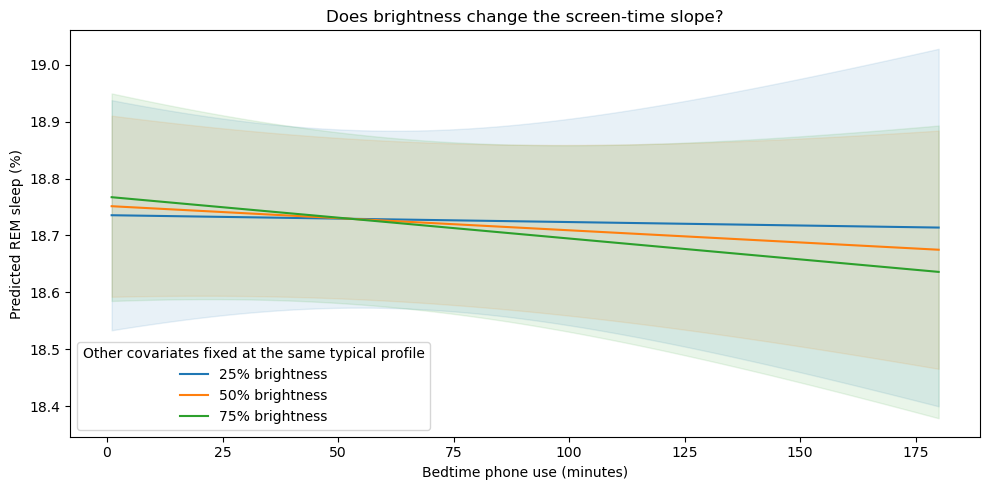

In [67]:
rem_brightness_model = smf.ols(rem_main_formula + ' + screen_30:brightness_25', data=rem_analysis).fit(cov_type='HC3')
rem_models['brightness'] = rem_brightness_model
brightness_scenarios = {'25% brightness': {'brightness_25': -1},
                        '50% brightness': {'brightness_25': 0},
                        '75% brightness': {'brightness_25': 1}}
display(rem_slope_table(rem_brightness_model, brightness_scenarios).round(4))
brightness_difference = rem_contrast(rem_brightness_model,
    rem_slope_vector(rem_brightness_model, {'brightness_25': 1}) -
    rem_slope_vector(rem_brightness_model, {'brightness_25': 0}))
display(pd.DataFrame([brightness_difference], index=['Slope change per +25 brightness percentage points']).round(4))
rem_interaction_test(rem_brightness_model, 'brightness')
rem_lines(rem_brightness_model, brightness_scenarios, 'Does brightness change the screen-time slope?')
rem_interpretations['brightness'] = (
    '**Outcome:** Increasing brightness by 25 percentage points changes the REM association '
    'per additional 30 phone minutes by ' + rem_effect_sentence(brightness_difference) + '. '
    'A negative difference means a larger screen-time penalty at higher brightness; a positive '
    'difference means a smaller penalty. The rows show the actual slopes at 25%, 50%, and 75% '
    'brightness. A vertical separation between lines alone is a brightness main effect, '
    'not evidence that brightness amplifies prolonged phone use.')

**Outcome:** Increasing brightness by 25 percentage points changes the REM association per additional 30 phone minutes by -0.009 REM percentage points (95% CI -0.056 to +0.038). A negative difference means a larger screen-time penalty at higher brightness; a positive difference means a smaller penalty. The rows show the actual slopes at 25%, 50%, and 75% brightness. A vertical separation between lines alone is a brightness main effect, not evidence that brightness amplifies prolonged phone use. **Interaction evidence:** p = 0.7001; BH-adjusted p = 0.8909. There is no clear evidence of a slope difference after accounting for the four planned tests; this does not prove the slopes are identical.

### Screen time × blue-light filter → REM

,REM pp per +30 min,95% CI lower,95% CI upper,p-value
Filter OFF,-0.0102,-0.0615,0.0411,0.6973
Filter ON,-0.0197,-0.0743,0.0349,0.4800


,REM pp per +30 min,95% CI lower,95% CI upper,p-value
Slope change: ON minus OFF,-0.0095,-0.0844,0.0654,0.8038


,n,over_90_minutes
filter_on,,
0,4524,835
1,3976,710


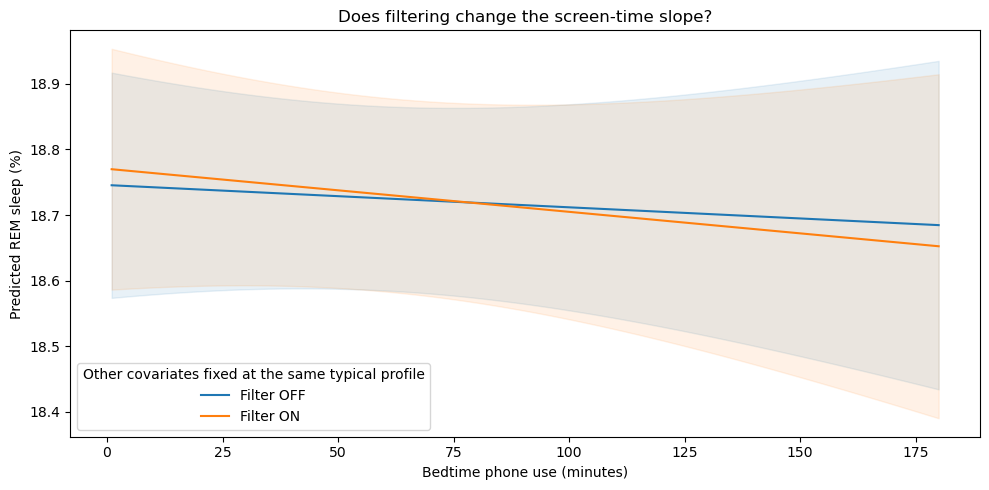

In [68]:
rem_filter_model = smf.ols(rem_main_formula + ' + screen_30:filter_on', data=rem_analysis).fit(cov_type='HC3')
rem_models['filter'] = rem_filter_model
filter_scenarios = {'Filter OFF': {'filter_on': 0}, 'Filter ON': {'filter_on': 1}}
display(rem_slope_table(rem_filter_model, filter_scenarios).round(4))
filter_difference = rem_contrast(rem_filter_model,
    rem_slope_vector(rem_filter_model, {'filter_on': 1}) -
    rem_slope_vector(rem_filter_model, {'filter_on': 0}))
display(pd.DataFrame([filter_difference], index=['Slope change: ON minus OFF']).round(4))
display(rem_analysis.assign(long_phone=rem_analysis.screen_30 > 3).groupby('filter_on').agg(
    n=('rem_pct', 'size'), over_90_minutes=('long_phone', 'sum')))
rem_interaction_test(rem_filter_model, 'filter')
rem_lines(rem_filter_model, filter_scenarios, 'Does filtering change the screen-time slope?')
rem_interpretations['filter'] = (
    '**Outcome:** Filter ON versus OFF changes the REM association per additional 30 phone '
    'minutes by ' + rem_effect_sentence(filter_difference) + '. A positive difference would '
    'suggest attenuation of a negative screen-time slope; a negative difference would suggest '
    'a larger penalty. This tests screen time × filter, not brightness × filter. '
    'Filter status is binary, and the group counts show how much long-use data support each '
    'comparison. Filter users may differ in unmeasured ways, so the estimate is not a causal benefit.')

**Outcome:** Filter ON versus OFF changes the REM association per additional 30 phone minutes by -0.009 REM percentage points (95% CI -0.084 to +0.065). A positive difference would suggest attenuation of a negative screen-time slope; a negative difference would suggest a larger penalty. This tests screen time × filter, not brightness × filter. Filter status is binary, and the group counts show how much long-use data support each comparison. Filter users may differ in unmeasured ways, so the estimate is not a causal benefit. **Interaction evidence:** p = 0.8038; BH-adjusted p = 0.8909. There is no clear evidence of a slope difference after accounting for the four planned tests; this does not prove the slopes are identical.

### Screen time × caffeine → REM

,REM pp per +30 min,95% CI lower,95% CI upper,p-value
0 mg after 5 pm,-0.0309,-0.0754,0.0136,0.1740
100 mg after 5 pm,0.0188,-0.0423,0.0799,0.5473
200 mg after 5 pm,0.0684,-0.0581,0.1949,0.2893


,REM pp per +30 min,95% CI lower,95% CI upper,p-value
Slope change per +100 mg evening caffeine,0.0496,-0.0229,0.1221,0.1797


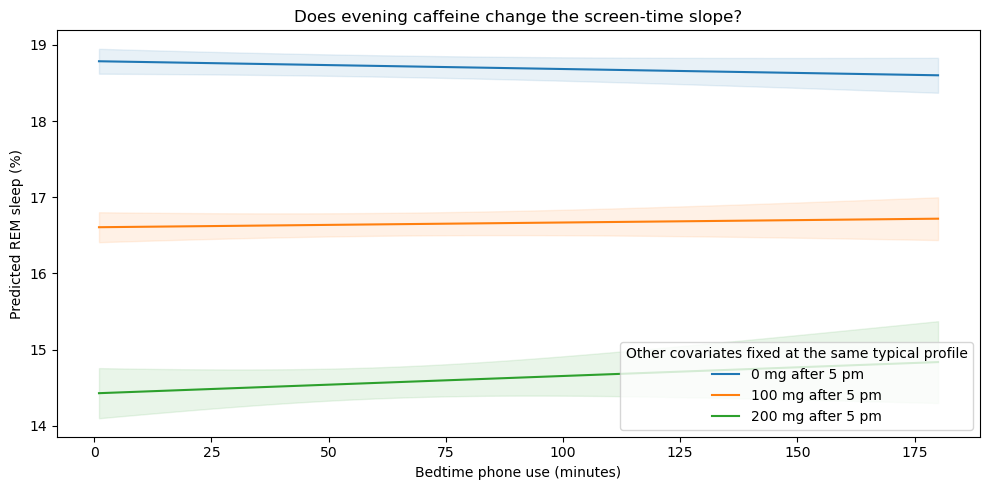

In [69]:
rem_caffeine_model = smf.ols(rem_main_formula + ' + screen_30:caffeine_100', data=rem_analysis).fit(cov_type='HC3')
rem_models['caffeine'] = rem_caffeine_model
caffeine_scenarios = {'0 mg after 5 pm': {'caffeine_100': 0},
                      '100 mg after 5 pm': {'caffeine_100': 1},
                      '200 mg after 5 pm': {'caffeine_100': 2}}
display(rem_slope_table(rem_caffeine_model, caffeine_scenarios).round(4))
caffeine_difference = rem_contrast(rem_caffeine_model,
    rem_slope_vector(rem_caffeine_model, {'caffeine_100': 1}) -
    rem_slope_vector(rem_caffeine_model, {'caffeine_100': 0}))
display(pd.DataFrame([caffeine_difference], index=['Slope change per +100 mg evening caffeine']).round(4))
rem_interaction_test(rem_caffeine_model, 'caffeine')
rem_lines(rem_caffeine_model, caffeine_scenarios, 'Does evening caffeine change the screen-time slope?')
rem_interpretations['caffeine'] = (
    '**Outcome:** An additional 100 mg of caffeine after 5 pm changes the REM association '
    'per additional 30 phone minutes by ' + rem_effect_sentence(caffeine_difference) + '. '
    'A negative difference would indicate a larger screen-time penalty with more caffeine. '
    'Caffeine can have a separate association with REM even if this interaction is weak. '
    'The lines assume a linear change in slope with caffeine dose; the 200 mg scenario may '
    'have less support than the lower-dose scenarios, so it should not be treated as an intervention estimate.')

**Outcome:** An additional 100 mg of caffeine after 5 pm changes the REM association per additional 30 phone minutes by +0.050 REM percentage points (95% CI -0.023 to +0.122). A negative difference would indicate a larger screen-time penalty with more caffeine. Caffeine can have a separate association with REM even if this interaction is weak. The lines assume a linear change in slope with caffeine dose; the 200 mg scenario may have less support than the lower-dose scenarios, so it should not be treated as an intervention estimate. **Interaction evidence:** p = 0.1797; BH-adjusted p = 0.7189. There is no clear evidence of a slope difference after accounting for the four planned tests; this does not prove the slopes are identical.

### Screen time × app choice → REM

,REM pp per +30 min,95% CI lower,95% CI upper,p-value,n,over_90_minutes,phone_minutes_min,phone_minutes_max
Instagram / Reddit,-0.0426,-0.1308,0.0455,0.3430,1630,313,2.0,180.0
Streaming (Netflix/Hulu),-0.0391,-0.1383,0.0600,0.4390,1301,203,2.0,180.0
News / Reading,-0.0362,-0.1770,0.1045,0.6139,596,105,5.0,180.0
TikTok / Reels,-0.0159,-0.0861,0.0544,0.6581,2198,430,2.0,180.0
YouTube,0.0141,-0.0653,0.0934,0.7284,1928,333,1.0,180.0
Messaging / Chat,0.0263,-0.0914,0.1441,0.6611,847,161,4.0,180.0


Joint robust F-test of all screen-time-by-app terms: p = 0.8909


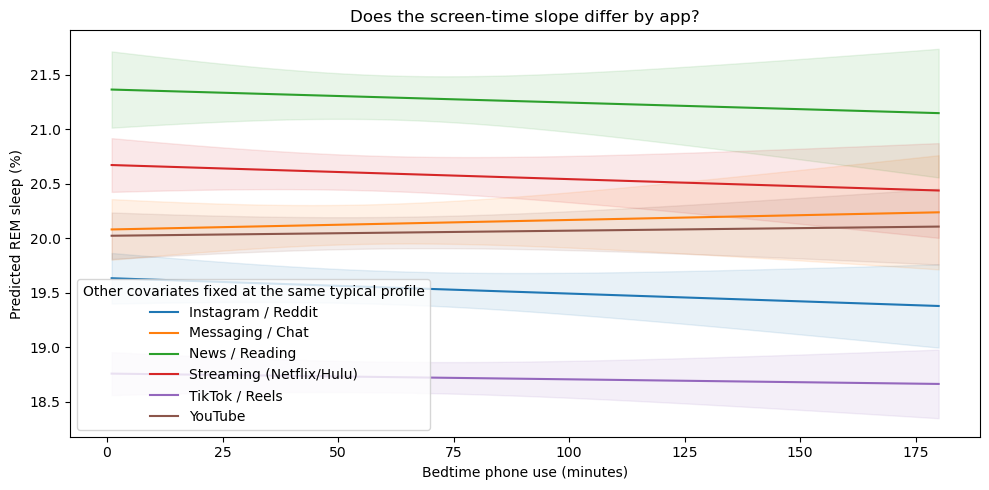

,interaction p-value,adjusted R2,BH-adjusted p-value,change in adjusted R2 vs baseline
brightness,0.70009,0.26835,0.89088,-0.00007
filter,0.80382,0.26834,0.89088,-0.00008
caffeine,0.17972,0.26849,0.71890,0.00007
app,0.89088,0.26814,0.89088,-0.00028


In [70]:
rem_app_model = smf.ols(rem_main_formula + ' + screen_30:C(bedtime_app)', data=rem_analysis).fit(cov_type='HC3')
rem_models['app'] = rem_app_model
app_scenarios = {name: {'bedtime_app': name} for name in sorted(rem_analysis.bedtime_app.unique())}
app_slopes = rem_slope_table(rem_app_model, app_scenarios)
app_support = rem_analysis.assign(long_phone=rem_analysis.screen_30 > 3).groupby('bedtime_app').agg(
    n=('rem_pct', 'size'), over_90_minutes=('long_phone', 'sum'),
    phone_minutes_min=('screen_30', lambda s: s.min() * 30),
    phone_minutes_max=('screen_30', lambda s: s.max() * 30))
display(app_slopes.join(app_support).sort_values('REM pp per +30 min').round(4))
app_joint_p = rem_interaction_test(rem_app_model, 'app')
print(f'Joint robust F-test of all screen-time-by-app terms: p = {app_joint_p:.4g}')
rem_lines(rem_app_model, app_scenarios, 'Does the screen-time slope differ by app?')
app_steepest = app_slopes['REM pp per +30 min'].idxmin()
app_flattest = app_slopes['REM pp per +30 min'].idxmax()
rem_interpretations['app'] = (
    '**Outcome:** The most negative estimated slope is for **' + app_steepest + '** ('
    + rem_effect_sentence(app_slopes.loc[app_steepest].to_dict()) + '), and the least negative '
    'is for **' + app_flattest + '** (' + rem_effect_sentence(app_slopes.loc[app_flattest].to_dict())
    + f'). The joint test asks whether any app slope differs (p = {app_joint_p:.4g}). '
    'Ranking the point estimates alone does not establish that the apps differ: the joint '
    'interaction test, intervals, and sample counts matter. These are broad primary-app '
    'categories, not measurements of content, scrolling intensity, or minutes spent in each app.')

# Correct across the four planned interaction hypotheses, including the joint app test.
rem_interaction_summary = pd.DataFrame(rem_interaction_tests).T
rem_interaction_summary['BH-adjusted p-value'] = multipletests(
    rem_interaction_summary['interaction p-value'], method='fdr_bh')[1]
rem_interaction_summary['change in adjusted R2 vs baseline'] = (
    rem_interaction_summary['adjusted R2'] - rem_baseline.rsquared_adj)
display(rem_interaction_summary.round(5))
for name in rem_interaction_tests:
    p = rem_interaction_summary.loc[name, 'interaction p-value']
    q = rem_interaction_summary.loc[name, 'BH-adjusted p-value']
    conclusion = ('There is evidence of a slope difference after accounting for the four planned tests.'
                  if q < 0.05 else 'There is no clear evidence of a slope difference after accounting for the four planned tests; this does not prove the slopes are identical.')
    rem_interpretations[name] += f' **Interaction evidence:** p = {p:.4g}; BH-adjusted p = {q:.4g}. ' + conclusion
supported = rem_interaction_summary.index[rem_interaction_summary['BH-adjusted p-value'] < 0.05].tolist()
rem_interpretations['summary'] = (
    '**Answer to the question:** ' +
    ('The interactions with evidence of different screen-time slopes are: ' + ', '.join(supported) + '. '
     if supported else 'None of these four interaction tests clearly identifies a behavior that makes the screen-time REM penalty larger or smaller in this dataset. ')
    + 'Distinguish a factor associated with lower REM overall from a factor that changes the penalty '
    'for an extra 30 minutes of screen time. The individual interpretations above quantify those '
    'slope changes. These models impose a constant screen-time slope within each exposure profile; '
    'they do not establish a special threshold for long use. Sparse combinations at the exposure '
    'extremes, nonlinear relationships, unmeasured confounding, and unknown dataset provenance '
    'limit the conclusions. The four-interaction correction does not adjust individual slope '
    'confidence intervals or establish pairwise differences between apps. REM percentage alone '
    'also does not capture the full sleep penalty, such as reduced total sleep or REM minutes.')

**Outcome:** The most negative estimated slope is for **Instagram / Reddit** (-0.043 REM percentage points (95% CI -0.131 to +0.045)), and the least negative is for **Messaging / Chat** (+0.026 REM percentage points (95% CI -0.091 to +0.144)). The joint test asks whether any app slope differs (p = 0.8909). Ranking the point estimates alone does not establish that the apps differ: the joint interaction test, intervals, and sample counts matter. These are broad primary-app categories, not measurements of content, scrolling intensity, or minutes spent in each app. **Interaction evidence:** p = 0.8909; BH-adjusted p = 0.8909. There is no clear evidence of a slope difference after accounting for the four planned tests; this does not prove the slopes are identical.

**Answer to the question:** None of these four interaction tests clearly identifies a behavior that makes the screen-time REM penalty larger or smaller in this dataset. The baseline screen-time slope is also close to zero, so a REM-percentage penalty is not established in the first place.  The individual interpretations above quantify those slope changes. These models impose a constant screen-time slope within each exposure profile; they do not establish a special threshold for long use. Sparse combinations at the exposure extremes, nonlinear relationships, unmeasured confounding, and unknown dataset provenance limit the conclusions. The four-interaction correction does not adjust individual slope confidence intervals or establish pairwise differences between apps. REM percentage alone also does not capture the full sleep penalty, such as reduced total sleep or REM minutes.
However, while there are no notable major changes, there are minor ones. For example, the increased mg of caffeine caused an increase in slope for more time in REM, the increase in brigthness caused a decrease in slope meaning less time in REM, and turning the blue light filter on brought greater time in REM. They all contribute to better sleep overall. There just isn't one big thing to change.